# 02 · Data center growth in California (RQ1)

Chapter 2 of *Mapping the Consumption Gap*. Reproduces the national construction-spending chart with rigor, tests for structural breaks, builds the California proxies, assembles every vintage of the CEC energization tiers, and answers RQ1 in a table.

Outputs are produced by `scripts/run_chapter2.py` from `src/ch2_growth.py`; this notebook displays them. Bootstrap p-values use 199 moving-block replications; rerunning the pipeline reproduces them exactly (fixed seeds).

| Step | Sources (manifest ids) |
|---|---|
| 1-2. Census chart, breaks, forecasts | `census_c30_privsatime`, `census_c30_privtime` |
| 3. California proxies | `qcew_518210_*`, `cbre_*_infogram_*` (via `cbre_california_market_series.csv`), `epoch_data_center_timelines`, `epoch_data_centers` |
| 4. Tier vintages | `cec_dc_forecast_2024iepr`, `cec_prelim_dc_forecast_2025`, `cec_dc_methodology_memo_2026`, `cec_assembly_hearing_2026_01_28`, `cec_tn266008`, `cec_tn268459`, `cec_tn272026` |
| 5. RQ1 denominators | `caiso_key_statistics_2026_08`, chapter 1 tables, `cec_tn268124`, `cec_tn268727`, `cec_tn268824` |


In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))
import pandas as pd, numpy as np
from IPython.display import Image, display
from src.paths import PROCESSED, FIGURES
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 80)
def show(name): display(Image(filename=str(FIGURES / f"{name}.png")))
def table(name, **kw): return pd.read_csv(PROCESSED / f"{name}.csv", **kw)

## 1. The Census chart, reproduced from the raw C30 workbook

US private construction spending in the Census Bureau's "Data center" category (a line item under nonresidential/office since January 2014), seasonally adjusted annual rate, millions of dollars. The second panel is month-over-month growth.

In [2]:
c = table("ch2_census_c30_data_center", index_col=0, parse_dates=True)
c[["data_center_saar","data_center_nsa","nonresidential_saar","dc_share_of_nonres_pct","mom_growth_pct","yoy_growth_pct","flag_saar"]].iloc[[0, 60, 106, 107, -3, -2, -1]].round(2)

,data_center_saar,data_center_nsa,nonresidential_saar,dc_share_of_nonres_pct,mom_growth_pct,yoy_growth_pct,flag_saar
date,,,,,,,
2014-01-31,1637.0,124.0,353903,0.46,NaN,NaN,NaN
2019-01-31,8116.0,631.0,458298,1.77,0.84,33.53,NaN
2022-11-30,13855.0,1120.0,649673,2.13,8.11,30.98,NaN
2022-12-31,14244.0,1153.0,663906,2.15,2.81,25.79,NaN
2026-05-31,65688.0,5627.0,749441,8.76,6.19,36.25,r
2026-06-30,70755.0,6122.0,752375,9.40,7.71,51.02,r
2026-07-31,75166.0,6551.0,755169,9.95,6.23,57.22,p


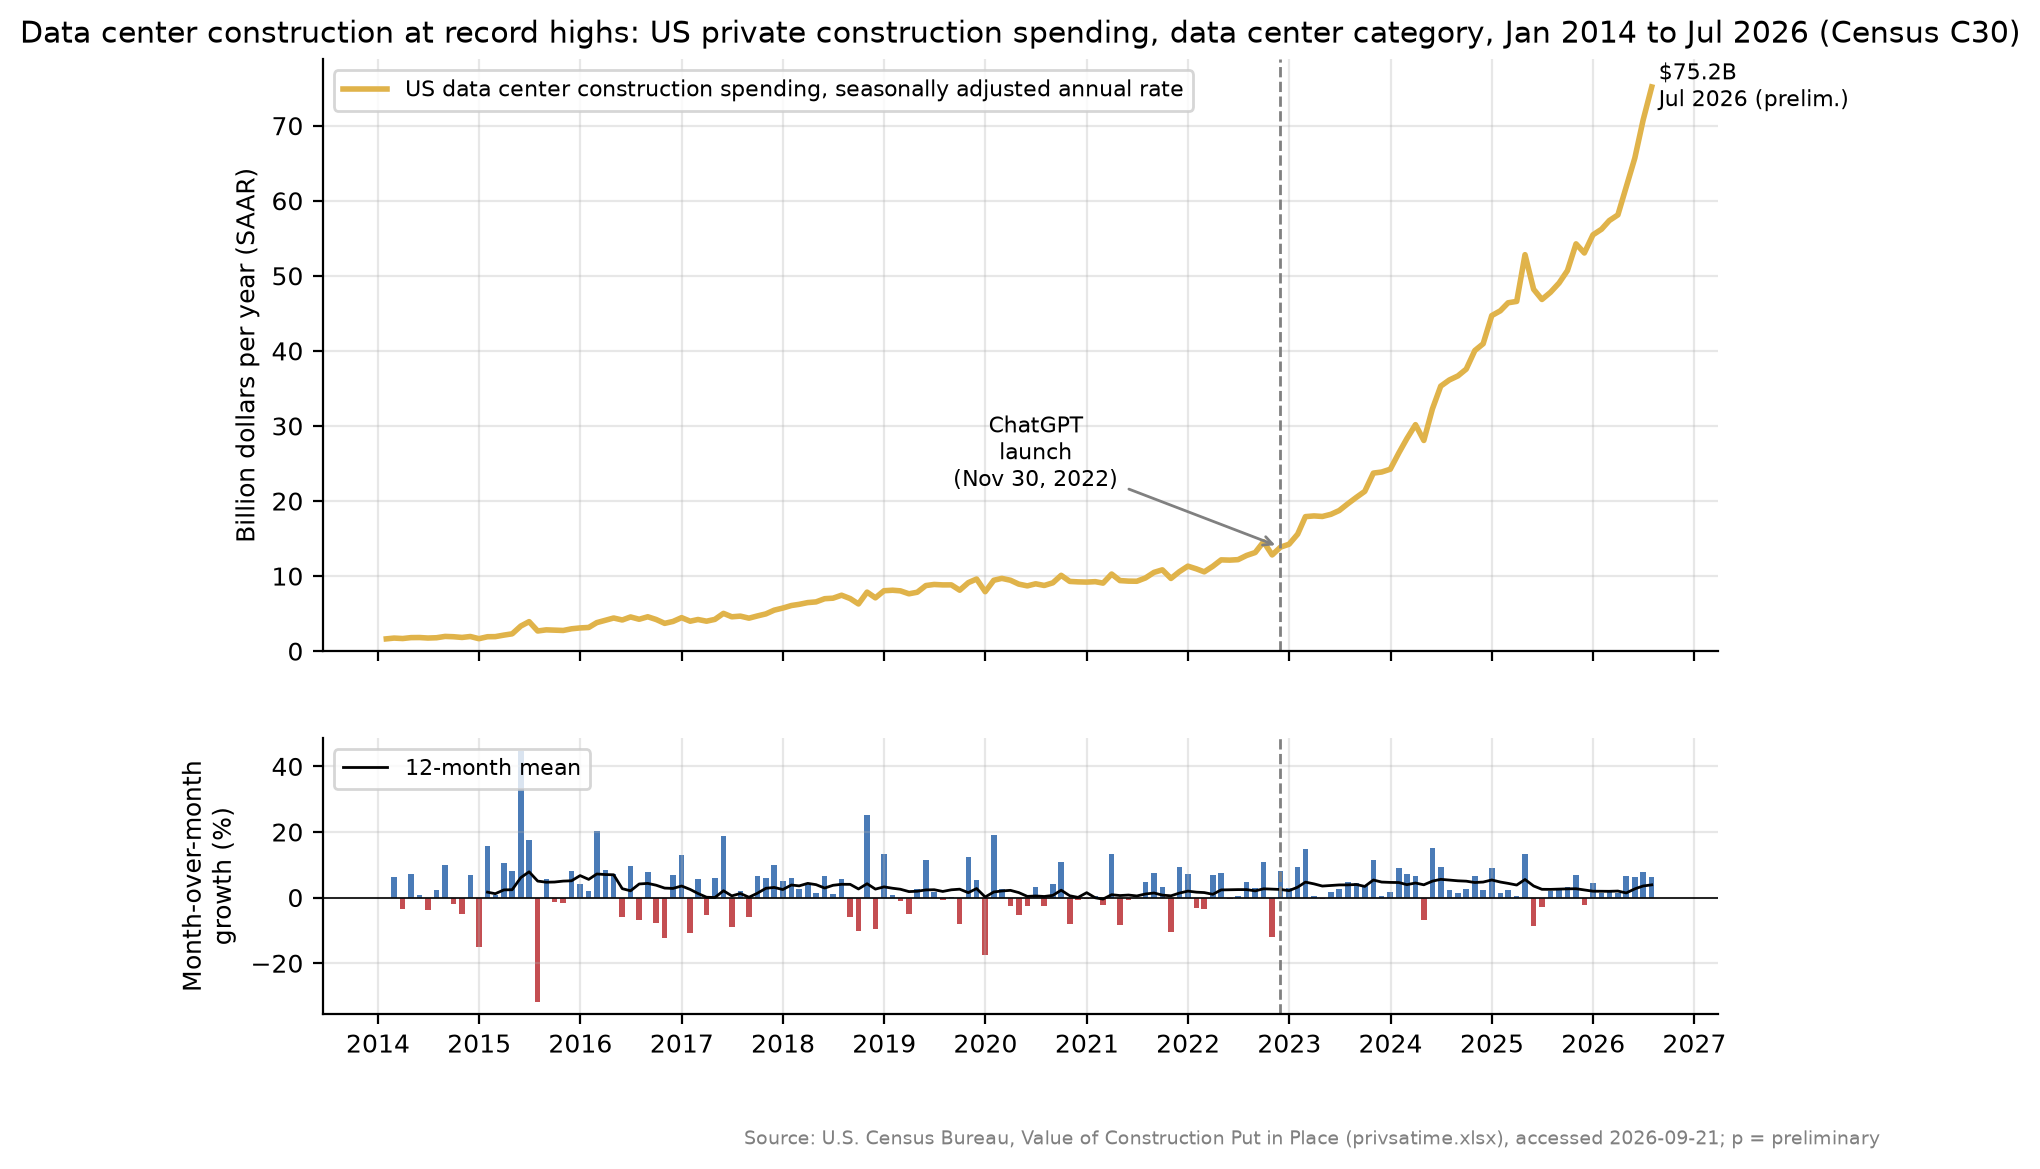

In [3]:
show("fig2_01_census_data_center_construction")

**Reading.** Spending rose from $1.6 billion a year in January 2014 to $13.9 billion in November 2022 and $75.2 billion in July 2026 (preliminary), and data centers went from 0.5 percent to 10 percent of all private nonresidential construction. Month-over-month growth averaged 4.1 percent in 2023-2026 against 1.2 percent in 2019-2021.

## 2. Structural breaks and forecasts on the log series

- **Chow test** at December 2022 (first month after the ChatGPT launch): break in intercept and slope of the log-linear trend, classical F plus a HAC-robust Wald test.
- **Bai-Perron**: global least-squares search over all partitions with 15 percent trimming (minimum segment 23 months), number of breaks chosen by BIC and LWZ; supF(0|1) with a moving-block residual bootstrap p-value; the single-break date with a residual-bootstrap 90 percent interval; `ruptures` dynamic programming as a cross-check.
- **Forecasts**: ARIMA(p,1,q) with drift chosen by AIC, and ETS with damped additive trend, both on log levels, 24 months ahead.

In [4]:
summ = json.loads((PROCESSED / "ch2_census_break_summary.json").read_text())
{k: summ[k] for k in ["chow_F","chow_p","wald_hac_p","cagr_pre","cagr_pre_lo","cagr_pre_hi","cagr_post","cagr_post_lo","cagr_post_hi","bp_break1","bp_break1_ci90","bp_supF_1","bp_supF_1_boot_p","bp_breaks_bic","bp_m_bic","bp_m_lwz","ruptures_dynp","arima","ets"]}

{'chow_F': 62.95985200809386,
 'chow_p': 0.0,
 'wald_hac_p': 1.4466646827943993e-09,
 'cagr_pre': 0.2630626272234078,
 'cagr_pre_lo': 0.21624808165115006,
 'cagr_pre_hi': 0.3116791091852893,
 'cagr_post': 0.5394156421081491,
 'cagr_post_lo': 0.46912880448988914,
 'cagr_post_hi': 0.6130651798023163,
 'bp_break1': '2020-11',
 'bp_break1_ci90': '2020-11 to 2020-11',
 'bp_supF_1': 125.44288008939989,
 'bp_supF_1_boot_p': 0.01,
 'bp_breaks_bic': '2016-10, 2018-12, 2022-03',
 'bp_m_bic': 3,
 'bp_m_lwz': 3,
 'ruptures_dynp': {'1': ['2020-10'],
  '2': ['2018-11', '2022-02'],
  '3': ['2016-09', '2018-11', '2022-02']},
 'arima': {'order': [1, 1, 1],
  'aic': -326.35099173744527,
  'drift_per_month': 0.025272101168361087,
  'params': {'x1': 0.025272101168361087,
   'ar.L1': 0.37168284740171426,
   'ma.L1': -0.6257906683665092,
   'sigma2': 0.006296327406195602}},
 'ets': {'aic': -317.9076415086508,
  'alpha': 0.7283599605396892,
  'beta': 0.029618434877879688,
  'phi': 0.98}}

In [5]:
table("ch2_census_bai_perron").round(3)

,m,breaks,ssr,bic,lwz,supF_0_m
0,0,NaN,5.967,-3.165,-3.101,NaN
1,1,2020-11,2.205,-4.061,-3.900,125.443
2,2,"2018-12, 2022-03",1.375,-4.433,-4.176,121.090
3,3,"2016-10, 2018-12, 2022-03",1.091,-4.565,-4.210,106.544


In [6]:
table("ch2_census_segment_growth").round(3)

,segment_start,segment_end,months,cagr,cagr_lo95,cagr_hi95
0,2014-01,2016-09,33,0.527,0.447,0.611
1,2016-10,2018-11,26,0.418,0.365,0.473
2,2018-12,2022-02,39,0.088,0.072,0.105
3,2022-03,2026-07,53,0.554,0.499,0.611


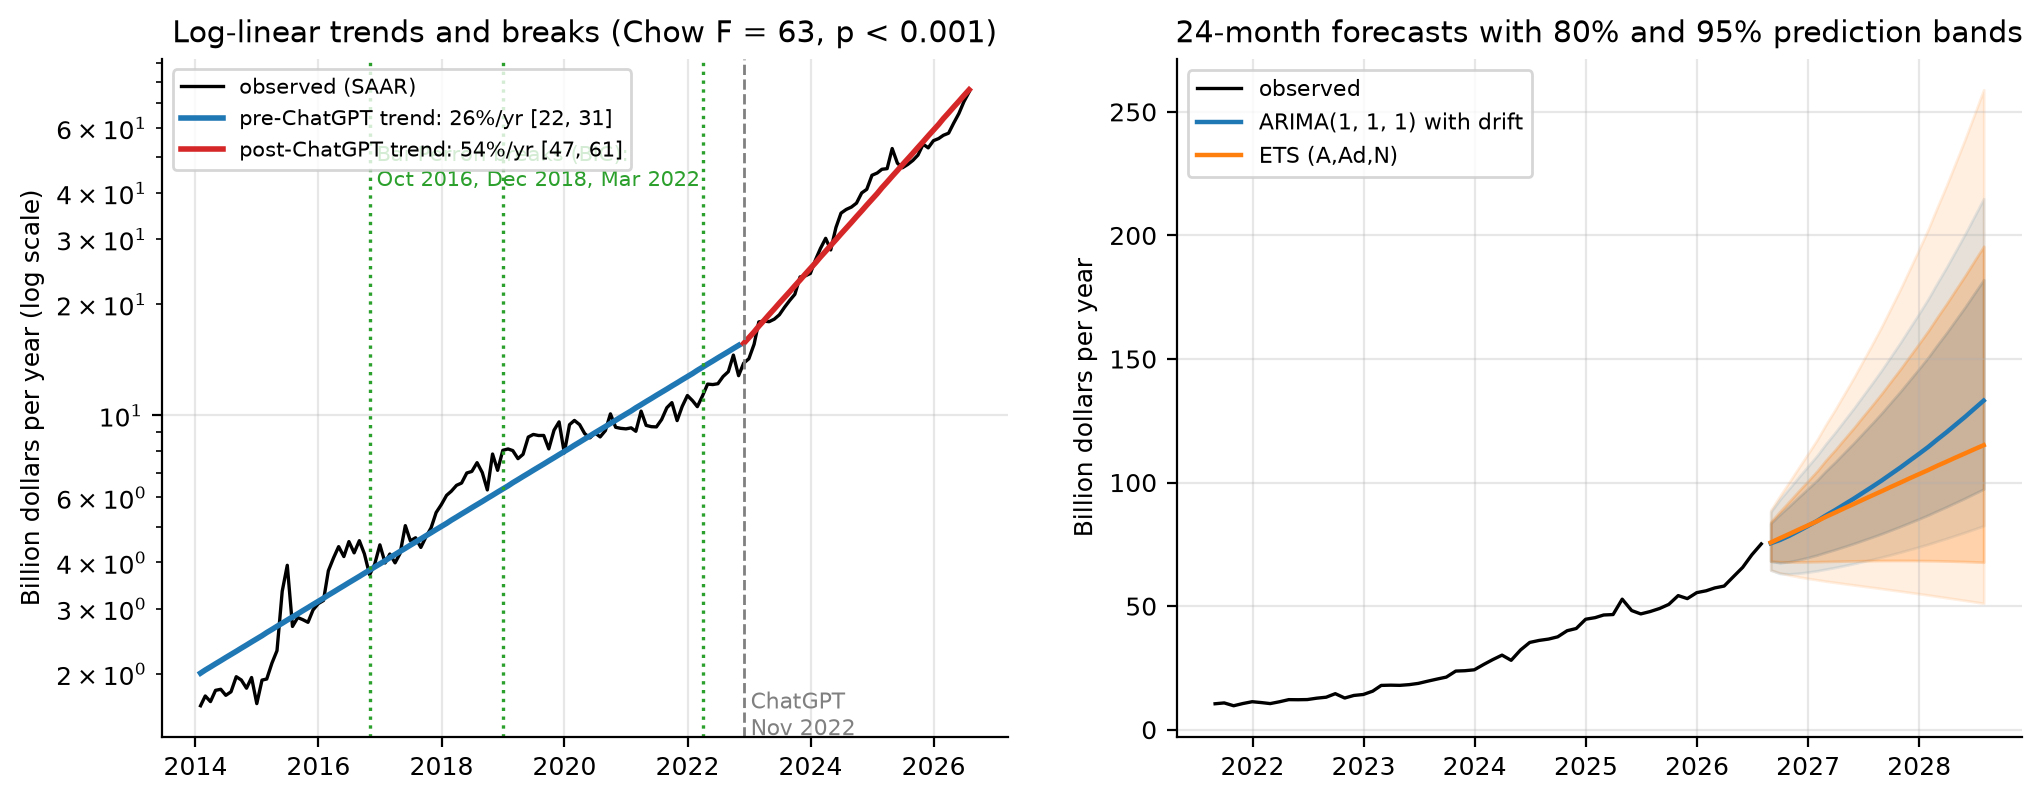

In [7]:
show("fig2_02_census_breaks_and_forecast")

In [8]:
fa = table("ch2_census_forecast_arima", index_col=0, parse_dates=True); fe = table("ch2_census_forecast_ets", index_col=0, parse_dates=True)
pd.concat({"ARIMA": (fa/1000).round(1), "ETS": (fe/1000).round(1)}, axis=1).iloc[[0, 5, 11, 17, 23]]

ARIMA                              ETS                          
             mean  lo80   hi80  lo95   hi95   mean  lo80   hi80  lo95   hi95
2026-08-31   75.4  68.1   83.5  64.6   88.1   75.7  68.2   84.0  64.6   88.8
2027-01-31   84.5  70.7  101.0  64.3  111.0   84.4  68.0  104.7  60.6  117.4
2027-07-31   98.3  78.0  124.0  68.9  140.2   94.8  68.4  131.3  57.6  156.0
2028-01-31  114.4  86.9  150.7  75.1  174.4  105.1  68.4  161.4  54.5  202.6
2028-07-31  133.2  97.4  182.1  82.5  214.9  115.1  67.8  195.6  51.2  258.9

**Reading.** The known-date test is unambiguous (Chow F = 63, p < 0.001; HAC Wald p < 0.001): compound growth was 26 percent a year [22, 31] before December 2022 and 54 percent a year [47, 61] after. Letting the data locate breaks changes the story in one respect: BIC and LWZ both choose three breaks, October 2016, December 2018 and March 2022, so the acceleration began eight months before ChatGPT, in the hyperscaler capital-spending ramp of early 2022. Growth in the last segment (March 2022 to July 2026) is 55 percent a year [50, 61]. The bootstrap confirms the single-break supF is far outside the no-break distribution (p = 0.01) and `ruptures` reproduces every break date within one month. Both forecasts continue the trend with wide bands: roughly $95-100 billion by July 2027 and $115-135 billion by July 2028, with 95 percent bands spanning $50-260 billion by then.

## 3. California proxies: QCEW, CBRE, Epoch

No state-level construction-spending series exists. Three proxies are tested with the same battery (Chow at the first period after November 2022, Bai-Perron):
- BLS QCEW, NAICS 518210, private, California: establishments, employment, wages by quarter (2015 Q1 to 2026 Q1).
- CBRE Silicon Valley colocation market: MW under construction each half-year since H1 2016 (chapter history table) and inventory (overview tables). Cushman & Wakefield's tables are gated; JLL gives single-period inventory only.
- Epoch AI frontier facilities: cumulative facility power from per-site timelines. Epoch lists no California site, so the California series is identically zero and only the national series can be tested.

In [9]:
comp = table("ch2_break_test_comparison")
comp[["series","n","start","end","known_break_period","chow_F","chow_p","wald_hac_p","cagr_pre","cagr_post","bp_break1","bp_break1_ci90","bp_breaks_bic","bp_supF_1_boot_p","note"]].round(3)

,series,n,start,end,known_break_period,chow_F,chow_p,wald_hac_p,cagr_pre,cagr_post,bp_break1,bp_break1_ci90,bp_breaks_bic,bp_supF_1_boot_p,note
0,"Census data center construction (monthly, SAAR)",151,2014-01,2026-07,2022-11,62.960,0.000,0.0,0.263,0.539,2020-11,2020-11 to 2020-11,"2016-10, 2018-12, 2022-03",0.010,NaN
1,QCEW 518210 California employment (quarterly),45,2015-03,2026-03,2023-03,23.928,0.000,0.0,0.099,-0.003,2023-03,2022-03 to 2024-03,"2020-12, 2023-03",0.065,NaN
2,QCEW 518210 California establishments (quarterly),45,2015-03,2026-03,2023-03,13.844,0.000,0.0,0.099,0.005,2022-09,2022-09 to 2023-06,"2020-03, 2023-09",0.095,NaN
3,QCEW 518210 California wages (quarterly),45,2015-03,2026-03,2023-03,3.227,0.050,0.0,0.201,0.112,2019-03,2017-06 to 2019-06,"2019-03, 2021-12",0.005,NaN
4,CBRE Silicon Valley MW under construction (semiannual),21,2016-06,2026-06,2023-06,0.501,0.614,0.0,0.349,0.040,2020-12,2020-12 to 2020-12,2020-12,0.140,NaN
5,"Epoch frontier sites, United States cumulative MW (monthly)",69,2021-01,2026-09,2022-11,176.134,0.000,0.0,0.000,2.883,2023-01,2023-01 to 2023-01,"2023-01, 2024-04",0.005,NaN
6,"Epoch frontier sites, California cumulative MW",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"no California site in the Epoch hub (0 of 87); series is identically zero, n..."


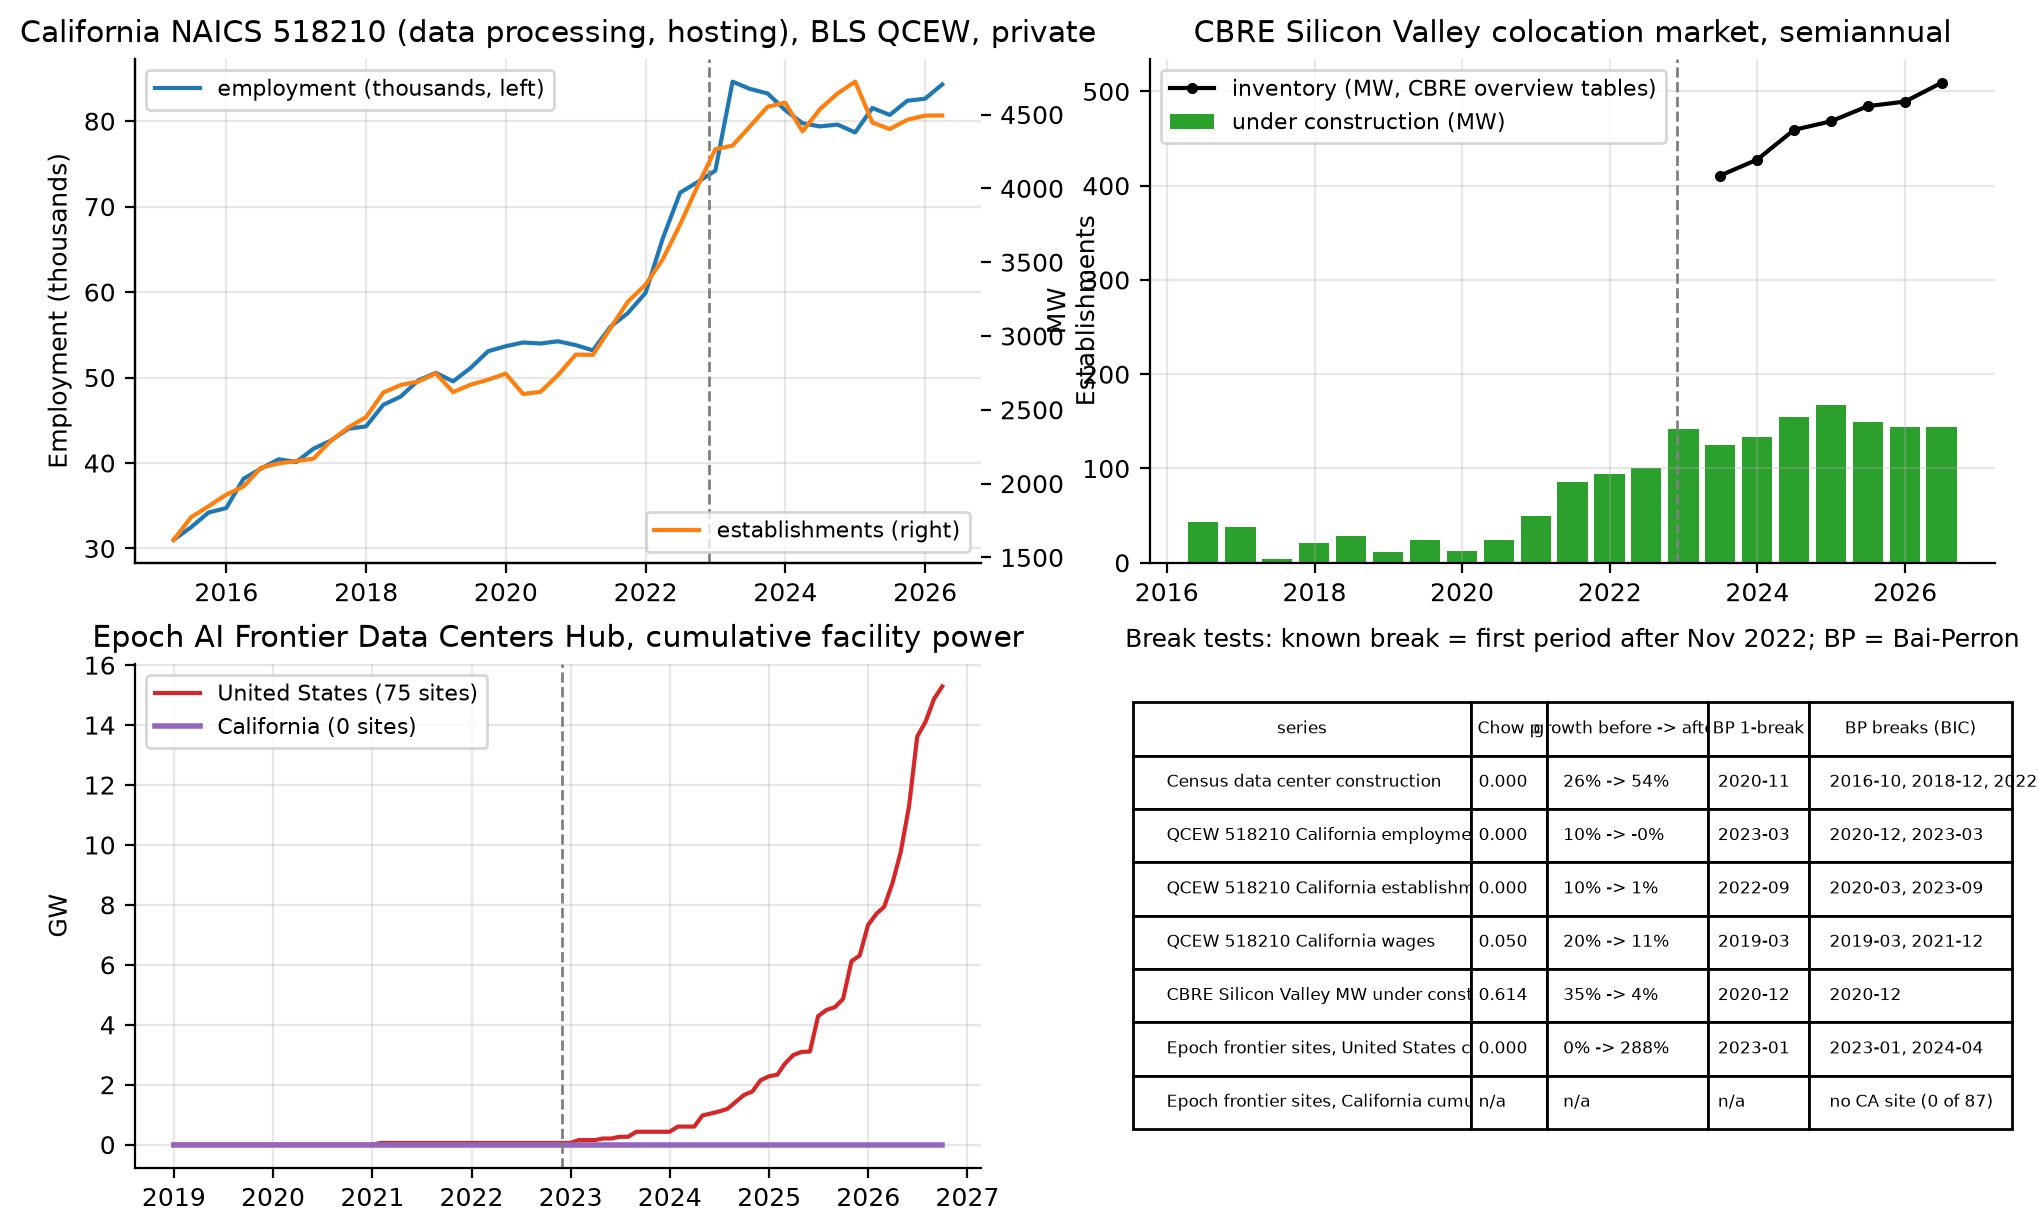

In [10]:
show("fig2_03_california_proxies")

In [11]:
q = table("ch2_qcew_518210_california"); q["fips"] = q.fips.astype(str).str.zfill(5)
st = q[q.fips=="06000"].set_index("period")[["qtrly_estabs","employment","total_qtrly_wages"]]
st.iloc[[0, 8, 16, 24, 31, 32, 36, 40, -1]]

,qtrly_estabs,employment,total_qtrly_wages
period,,,
2015-03-31,1619,31011.000000,969209666
2017-03-31,2169,41671.666667,1686315288
2019-03-31,2620,49552.333333,2516233157
2021-03-31,2872,53179.000000,3629122328
2022-12-31,4265,74211.000000,4539630613
2023-03-31,4290,84623.000000,5170479387
2024-03-31,4386,79752.666667,5763605974
2025-03-31,4446,81544.666667,6482297063
2026-03-31,4494,84295.333333,7191825181


In [12]:
cb = table("ch2_cbre_california"); cb[(cb.kind=="chapter_history")&(cb.metric=="under_construction_mw")][["period","value","edition"]].reset_index(drop=True).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
period,H1 2016,H2 2016,H1 2017,H2 2017,H1 2018,H2 2018,H1 2019,H2 2019,H1 2020,H2 2020,H1 2021,H2 2021,H1 2022,H2 2022,H1 2023,H2 2023,H1 2024,H2 2024,H1 2025,H2 2025,H1 2026
value,43.5,37.5,4.5,21.0,28.0,11.0,24.0,12.0,24.6,50.1,85.3,94.6,100.6,141.6,125.0,133.0,154.2,167.8,148.8,144.0,144.0
edition,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H1 2026 chapter history


**Reading.** The California proxies move the opposite way from the national construction series. QCEW employment in data processing and hosting grew 10 percent a year through 2022, then flattened (−0.3 percent a year after 2023 Q1, Chow p < 0.001); establishments show the same pattern and Bai-Perron places their break at 2022 Q3 to 2023 Q1. Silicon Valley's construction pipeline rose from about 44 MW in 2016 to 142 MW by late 2022 and has since sat between 125 and 168 MW with no break at 2023 (Chow p = 0.61), while the national frontier-site series went from nothing to 15 GW. Epoch's inventory has no California site. In short, the post-2022 boom shows up in California only as requests to connect, not as built or staffed capacity, which is consistent with the power constraints Silicon Valley Power and CBRE both describe.

## 4. Every vintage of the CEC energization tiers

Vintages found in the record: December 2024 (PG&E and SCE agreements plus applications, from the 2024 IEPR Update comparison), summer 2025 (seven utilities, totals only; the tier split was shown graphically), December 2025 (seven utilities by tier, methodology memo Table 1 and the Assembly slide), the August 2026 workshop (restates December 2025), and SCE's two public project databases (August 2025 and January 2026), the only utility-level vintages with cancellations. The June 2026 known-load charts in the 2026 IEPR workshop are images without numbers; the monthly snapshot watches docket 26-IEPR-03 for the next vintage.

In [13]:
tv = table("ch2_tier_vintages"); tv.pivot_table(index=["vintage","label"], columns="tier", values="mw", aggfunc="sum").fillna(0).round(0)

tier                                           Active application  Agreements + applications (no inquiries)  All tiers  Canceled  Inquiry  Signed agreement  Total restated
vintage label                                                                                                                                                              
2024-12 Dec 2024 (2024 IEPR Update)                           0.0                                    6771.0        0.0       0.0      0.0               0.0             0.0
2025-08 SCE database Aug 29 2025                            216.0                                       0.0        0.0     709.0   5934.0              51.0             0.0
        Summer 2025 (2025 IEPR preliminary)                   0.0                                       0.0    21756.0       0.0      0.0               0.0             0.0
2025-12 Dec 2025 (2025 IEPR final)                         9587.0                                       0.0        0.0       0.0   8605.0            5086.0             0.0
2026-01 SCE database Jan 29 2026                           3313.0                                       0.0        0.0    3137.0   1772.0              76.0             0.0
2026-08 Aug 2026 workshop (restates Dec 2025)                 0.0                                       0.0        0.0       0.0      0.0               0.0         23278.0

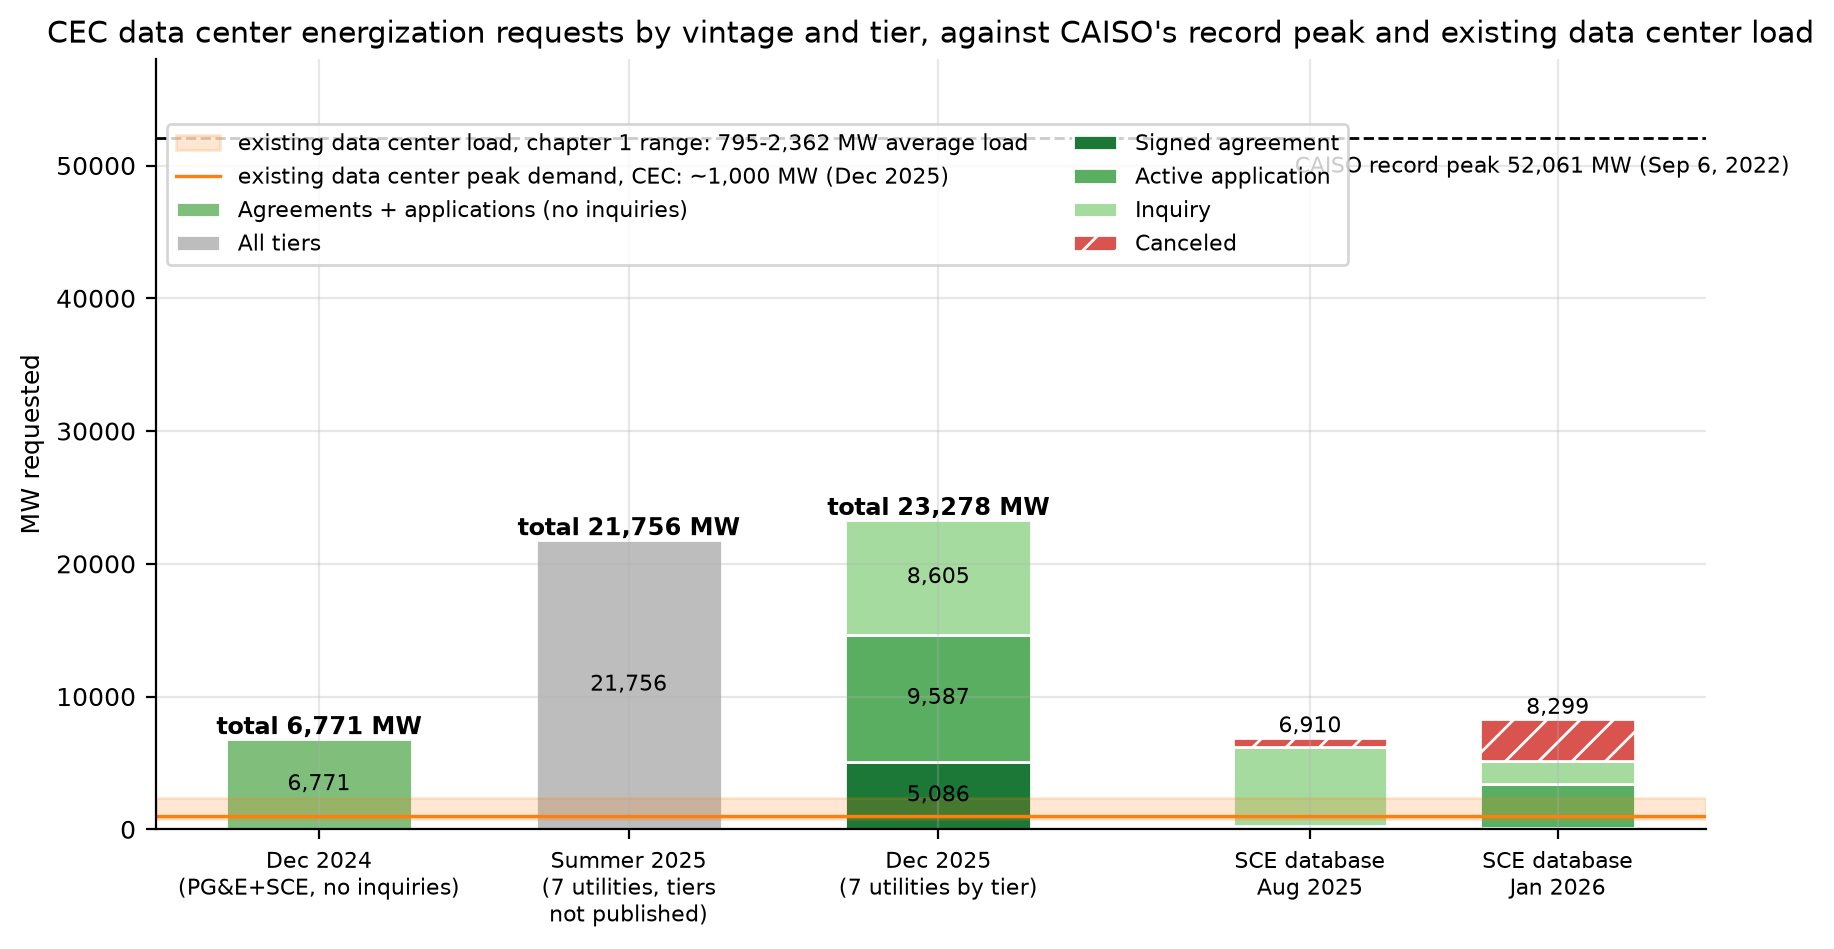

In [14]:
show("fig2_04_tier_vintages")

In [15]:
table("ch2_cec_forecast_reference_points")

,vintage,scenario,year,mw,note,source
0,2024-12,2024 IEPR Update mid (Dec),2024,987,existing + forecast total data center peak demand,cec_dc_forecast_2024iepr p.9
1,2024-12,2024 IEPR Update mid (Dec),2025,1190,NaN,cec_dc_forecast_2024iepr p.9
2,2024-12,2024 IEPR Update mid (Dec),2030,3294,NaN,cec_dc_forecast_2024iepr p.9
3,2024-12,2024 IEPR Update mid (Dec),2040,4507,NaN,cec_dc_forecast_2024iepr p.9
4,2025-12,2025 IEPR Planning (mid),2025,413,"incremental beyond ~1,000 MW existing",cec_dc_methodology_memo_2026 Fig. 4
5,2025-12,2025 IEPR Planning (mid),2040,4855,incremental,cec_dc_methodology_memo_2026 Fig. 4
6,2025-12,2025 IEPR Local Reliability (high),2025,684,incremental,cec_dc_methodology_memo_2026 Fig. 5
7,2025-12,2025 IEPR Local Reliability (high),2040,7381,incremental,cec_dc_methodology_memo_2026 Fig. 5
8,2025-12,Existing data center peak demand,2025,1000,as of December 2025,cec_dc_methodology_memo_2026 p.2


**Reading.** Requests grew from 6,771 MW (December 2024, two utilities, no inquiries) to 21,756 MW (summer 2025) and 23,277 MW (December 2025): 5,086 MW signed, 9,587 MW in application, 8,604 MW in inquiry. The sum is 45 percent of CAISO's record peak of 52,061 MW and 23 times the roughly 1,000 MW of existing data center peak demand the CEC reports, or 10 to 29 times the chapter 1 range of existing average load. SCE's public database shows what happens inside a vintage: between August 2025 and January 2026 its inquiries fell from 5,934 MW to 1,772 MW as 3,100 MW moved into applications, and canceled requests rose from 709 MW to 3,137 MW, so 38 percent of everything SCE had ever logged was canceled within five months.

## 5. RQ1: the pipeline by stage against the grid, existing load and the adopted forecast

In [16]:
rq = table("ch2_rq1_table"); rq.round(1)

,stage,mw,share_of_caiso_record_peak_pct,share_of_caiso_2025_peak_pct,multiple_of_existing_dc_peak_1000MW,multiple_of_existing_dc_avg_load_range,share_of_IEPR_planning_managed_net_peak_growth_2025_2030_pct,share_of_IEPR_planning_baseline_consumption_peak_growth_2025_2030_pct,expected_demand_at_67pct_utilization_mw,expected_demand_share_of_managed_net_peak_growth_pct,energy_equivalent_GWh_at_67pct_util_and_0p88_lf,energy_share_of_IEPR_statewide_energy_growth_2025_2030_pct
0,Signed agreements,5086.0,9.8,11.6,5.1,2.2-6.4,126.5,89.6,3407.6,84.8,26268.7,75.1
1,Active applications,9587.0,18.4,21.9,9.6,4.1-12.1,238.5,168.8,6423.3,159.8,49515.9,141.6
2,Inquiries,8604.0,16.5,19.6,8.6,3.6-10.8,214.1,151.5,5764.7,143.4,44438.8,127.1
3,"Total, three tiers",23277.0,44.7,53.1,23.3,9.9-29.3,579.2,410.0,15595.6,388.0,120223.3,343.8


In [17]:
den = json.loads((PROCESSED / "ch2_rq1_denominators.json").read_text()); {k: round(v, 1) for k, v in den.items()}

{'caiso_record_peak_mw': 52061.0,
 'caiso_record_hourly_eia930_mw': 51104.0,
 'caiso_2025_peak_mw': 43860.0,
 'existing_dc_peak_mw_cec': 1000.0,
 'existing_dc_avg_load_mw_low': 794.8,
 'existing_dc_avg_load_mw_high': 2361.6,
 'iepr_planning_caiso_managed_net_peak_2025_mw': 46479.0,
 'iepr_planning_caiso_managed_net_peak_2030_mw': 50498.0,
 'iepr_planning_caiso_baseline_consumption_peak_2025_mw': 50502.0,
 'iepr_planning_caiso_baseline_consumption_peak_2030_mw': 56180.0,
 'iepr_planning_data_center_at_caiso_peak_2025_mw': 96.0,
 'iepr_planning_data_center_at_caiso_peak_2030_mw': 1743.0,
 'iepr_planning_statewide_energy_growth_2025_2030_GWh': 34971.0,
 'iepr_planning_statewide_data_center_deliveries_2030_GWh': 12078.1,
 'iepr_planning_statewide_data_center_deliveries_2025_GWh': 729.1,
 'iepr_planning_statewide_energy_2025_GWh': 263195.7,
 'iepr_planning_statewide_energy_2030_GWh': 298166.7,
 'total_tiers_mw': 23277.0,
 'ratio_total_to_caiso_record_peak': 0.4,
 'ratio_total_to_caiso_recor

In [18]:
table("ch2_ced2025_planning_totals")[["metric","scope","y2025","y2030","y2040"]].round(0)

,metric,scope,y2025,y2030,y2040
0,energy_to_serve_load,Statewide total,263196.0,298167.0,399850.0
1,net_peak_1in2,Statewide coincident,57560.0,62832.0,75452.0
2,net_peak_1in2,Statewide noncoincident,60343.0,65522.0,78208.0
3,deliveries_total,Statewide total,242843.0,273316.0,364460.0
4,deliveries_total,Statewide excl. pumping,234598.0,265071.0,356215.0
5,data_center_deliveries,Statewide total (sum of planning-area totals),729.0,12078.0,32630.0
6,data_center_deliveries,PG&E Total,660.0,10940.0,27023.0
7,data_center_deliveries,SCE Total,69.0,1138.0,5607.0
8,data_center_deliveries,SDG&E Total,0.0,0.0,0.0
9,data_center_deliveries,NCNC Total,0.0,0.0,0.0


**Answer to RQ1.** By stage, California's planned data center capacity is 5,086 MW signed, 9,587 MW in application and 8,604 MW in inquiry, 23,277 MW in total (December 2025). That total is 45 percent of CAISO's all-time peak and 53 percent of the 2025 peak; 23 times the state's existing data center peak demand; and 5.8 times the growth in CAISO's managed net peak that the adopted 2025 IEPR planning forecast projects between 2025 and 2030 (4,019 MW). Even at the CEC's 67 percent utilization the pipeline is 3.9 times that growth, and its energy equivalent (about 120 TWh a year) is 3.4 times the statewide energy growth the forecast expects over the same period. The CEC's own forecast already embeds part of this: its data center component at the CAISO peak rises from 96 MW in 2025 to 1,743 MW in 2030 in the planning scenario (4,377 MW in the local-reliability scenario), and its data-center-only deliveries reach 12.1 TWh in 2030, about a third of projected statewide energy growth. The gap between requests and forecast is the object of the rest of the study.